In [6]:
analysis_year = 2025
traffic_rel_path = "Data/Trafficdata/traffic_25.csv"

In [7]:
from pathlib import Path
import platform

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

project_root = Path.cwd().resolve()
if not (project_root / traffic_rel_path).exists() and (project_root.parent / traffic_rel_path).exists():
    project_root = project_root.parent

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "Malgun Gothic"

plt.rcParams["axes.unicode_minus"] = False


In [8]:
traffic_path = project_root / traffic_rel_path
traffic_df = pd.read_csv(traffic_path)
traffic_df["일자"] = pd.to_datetime(traffic_df["일자"].astype(str), format="%Y%m%d")
traffic_df["날짜타입"] = traffic_df["일자"].dt.weekday.map(lambda x: "주말" if x >= 5 else "평일")

selected_bridges = ["서강대교", "마포대교", "원효대교"]
hour_cols = sorted(
    [col for col in traffic_df.columns if col.endswith("시") and col[:-1].isdigit()],
    key=lambda col: int(col[:-1]),
)

filtered_df = traffic_df[traffic_df["지점명"].isin(selected_bridges)].copy()
cleaned_df = filtered_df[["지점명", "일자", "날짜타입", "방향"] + hour_cols].copy()
display(cleaned_df.head())


,지점명,일자,날짜타입,방향,0시,1시,2시,3시,4시,5시,...,14시,15시,16시,17시,18시,19시,20시,21시,22시,23시
0,서강대교,2025-01-01,평일,유입,349.0,450.0,195.0,110.0,87.0,97.0,...,620.0,711.0,705.0,645.0,516.0,436.0,426.0,378.0,272.0,191.0
1,서강대교,2025-01-01,평일,유출,598.0,444.0,251.0,168.0,124.0,161.0,...,585.0,608.0,607.0,579.0,479.0,426.0,447.0,474.0,278.0,213.0
2,마포대교,2025-01-01,평일,유입,1037.0,1167.0,564.0,444.0,388.0,504.0,...,1983.0,2168.0,1947.0,1815.0,1714.0,1585.0,1672.0,1476.0,1086.0,609.0
3,마포대교,2025-01-01,평일,유출,1068.0,925.0,400.0,279.0,232.0,315.0,...,1936.0,2052.0,1995.0,2059.0,1940.0,1633.0,1648.0,1408.0,932.0,525.0
4,원효대교,2025-01-01,평일,유입,442.0,373.0,294.0,171.0,207.0,279.0,...,1111.0,1222.0,1174.0,1007.0,744.0,675.0,642.0,587.0,388.0,298.0


In [9]:
station_avg_df = (
    cleaned_df
    .groupby(["지점명", "날짜타입", "방향"], as_index=False)[hour_cols]
    .mean()
)

median_df = station_avg_df.melt(
    id_vars=["지점명", "날짜타입", "방향"],
    value_vars=hour_cols,
    var_name="시간",
    value_name="평균값",
)
median_df["시간_순서"] = median_df["시간"].str.extract(r"(\d+)").astype(int)
median_df = (
    median_df
    .groupby(["날짜타입", "방향", "시간", "시간_순서"], as_index=False)["평균값"]
    .median()
    .rename(columns={"평균값": "중앙값"})
    .sort_values(["날짜타입", "방향", "시간_순서"])
    .reset_index(drop=True)
)

display(station_avg_df.head())
display(median_df.head())


,지점명,날짜타입,방향,0시,1시,2시,3시,4시,5시,6시,...,14시,15시,16시,17시,18시,19시,20시,21시,22시,23시
0,마포대교,주말,유입,929.625000,719.278846,547.846154,436.701923,443.317308,844.288462,1399.740385,...,3026.701923,2986.442308,2966.375000,2811.105769,2489.663462,2239.846154,2318.701923,1919.807692,1573.284314,1028.960784
1,마포대교,주말,유출,892.144231,577.528846,425.009615,323.548077,347.701923,580.413462,894.086538,...,2883.557692,2944.009615,2959.701923,2887.682692,2654.451923,2339.663462,2296.788462,2100.221154,1655.087379,1007.941748
2,마포대교,평일,유입,915.244186,655.034884,461.553846,366.273077,510.922481,1391.621622,2722.776062,...,3096.484496,2995.046512,3166.821705,3613.298450,3442.868217,2748.934109,2515.794574,2338.313953,1959.855469,1418.961089
3,마포대교,평일,유출,781.694981,505.671815,370.853282,304.248062,414.119691,830.227799,1859.563707,...,2770.418605,2964.705426,3230.841085,3207.414729,3087.058140,3063.856589,2766.046512,2528.856589,2177.042969,1413.105469
4,서강대교,주말,유입,233.398058,186.621359,150.543689,115.310680,102.902913,190.737864,300.980583,...,1036.134615,1026.097087,1085.291262,1003.392157,898.941176,644.735294,591.504854,545.339806,399.480392,266.735294


,날짜타입,방향,시간,시간_순서,중앙값
0,주말,유입,0시,0,458.009615
1,주말,유입,1시,1,382.076923
2,주말,유입,2시,2,304.201923
3,주말,유입,3시,3,237.942308
4,주말,유입,4시,4,242.057692


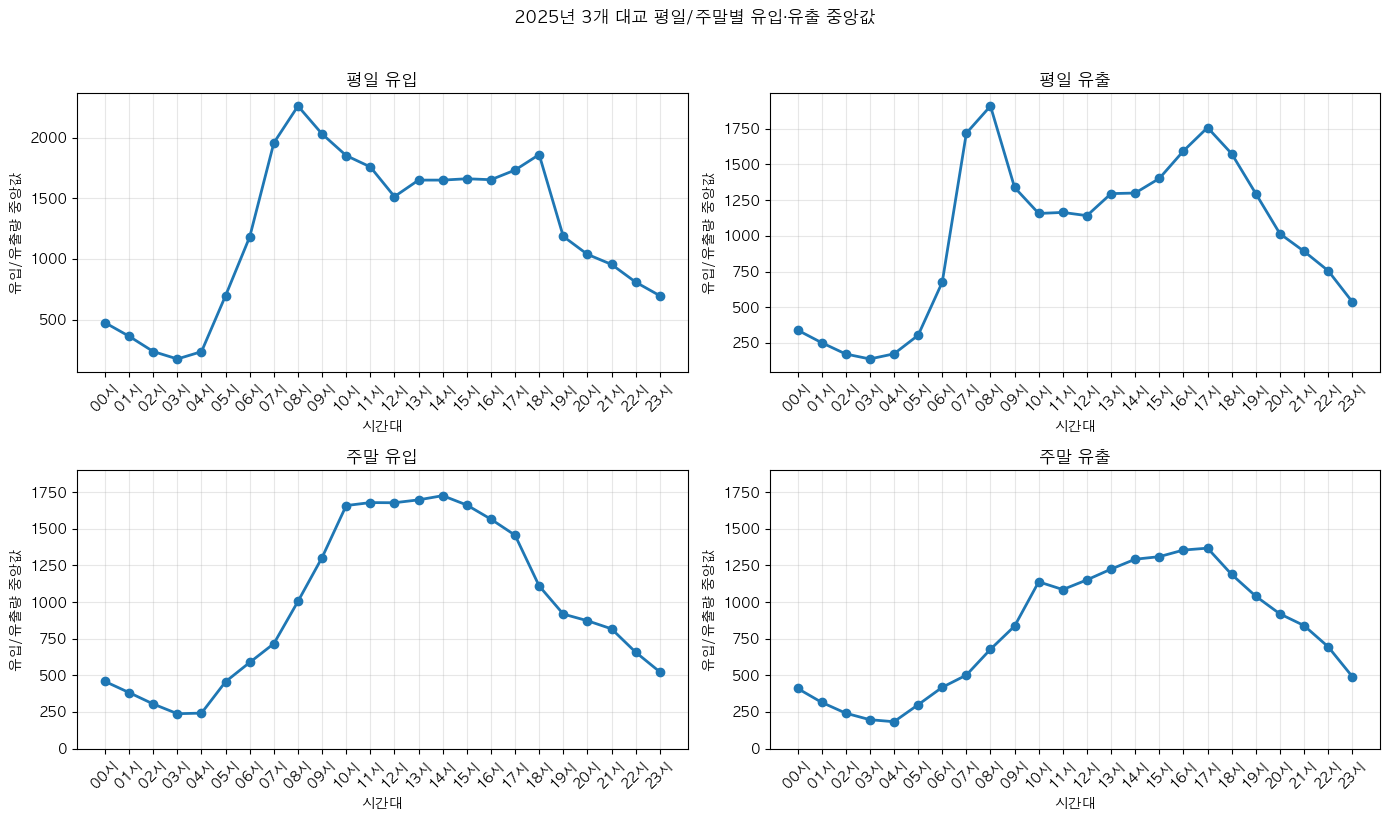

In [10]:
plot_order = [("평일", "유입"), ("평일", "유출"), ("주말", "유입"), ("주말", "유출")]
weekend_max = median_df[median_df["날짜타입"] == "주말"]["중앙값"].max()
weekend_ymax = weekend_max * 1.1 if pd.notna(weekend_max) else None

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)

for ax, (date_type, direction) in zip(axes.flatten(), plot_order):
    subset = median_df[(median_df["날짜타입"] == date_type) & (median_df["방향"] == direction)].sort_values("시간_순서")
    ax.plot(subset["시간_순서"], subset["중앙값"], marker="o", linewidth=2)
    ax.set_title(f"{date_type} {direction}")
    ax.set_xlabel("시간대")
    ax.set_ylabel("유입/유출량 중앙값")
    ax.set_xticks(range(24))
    ax.set_xticklabels([f"{hour:02d}시" for hour in range(24)], rotation=45)
    if date_type == "주말" and weekend_ymax is not None:
        ax.set_ylim(0, weekend_ymax)
    ax.grid(alpha=0.3)

fig.suptitle(f"{analysis_year}년 3개 대교 평일/주말별 유입·유출 중앙값", y=1.02)
fig.tight_layout()
plt.show()


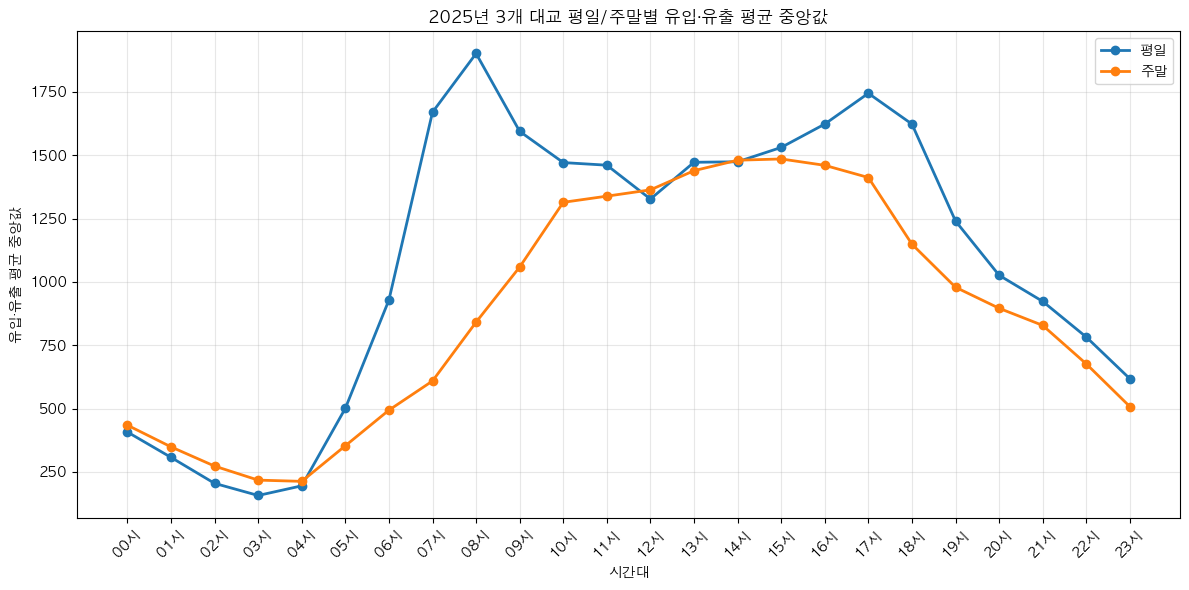

In [11]:
# Combined Weekday/Weekend Summary
combined_station_avg_df = (
    station_avg_df
    .groupby(["지점명", "날짜타입"], as_index=False)[hour_cols]
    .mean()
)

combined_median_df = combined_station_avg_df.melt(
    id_vars=["지점명", "날짜타입"],
    value_vars=hour_cols,
    var_name="시간",
    value_name="평균값",
)
combined_median_df["시간_순서"] = combined_median_df["시간"].str.extract(r"(\d+)").astype(int)
combined_median_df = (
    combined_median_df
    .groupby(["날짜타입", "시간", "시간_순서"], as_index=False)["평균값"]
    .median()
    .rename(columns={"평균값": "중앙값"})
    .sort_values(["날짜타입", "시간_순서"])
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(12, 6))
for date_type, color in [("평일", "#1f77b4"), ("주말", "#ff7f0e")]:
    subset = combined_median_df[combined_median_df["날짜타입"] == date_type].sort_values("시간_순서")
    ax.plot(subset["시간_순서"], subset["중앙값"], marker="o", linewidth=2, label=date_type, color=color)

ax.set_title(f"{analysis_year}년 3개 대교 평일/주말별 유입·유출 평균 중앙값")
ax.set_xlabel("시간대")
ax.set_ylabel("유입·유출 평균 중앙값")
ax.set_xticks(range(24))
ax.set_xticklabels([f"{hour:02d}시" for hour in range(24)], rotation=45)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
